In [1]:
import sys
import cv2
import json
import numpy as np
from matplotlib import pyplot as plt

from pathlib import Path
from pprint import pprint
from torchvision.transforms.functional import to_pil_image

# lerobot
from lerobot.datasets.lerobot_dataset import LeRobotDataset
from lerobot.datasets.dataset_tools import add_feature, remove_feature
from lerobot.constants import OBS_ENV_STATE 

# yolo
from ultralytics import YOLO
from yolo_utils import yolo_postprocess_res, yolo_preprocess, yolo_draw_center_orientation, YOLO_ANN_COLORS

# paths
sys.path.append(str(Path().resolve().parent))
from paths import REPO_ROOT, DATASETS_DIR, HF_NAME, POLICIES_DIR

# set up env secrets
from dotenv import load_dotenv
load_dotenv(REPO_ROOT/".env", override=True)

# magic autoreload
%load_ext autoreload
%autoreload 2

/home/jonathan/miniforge3/envs/lerobot-sim-real-sim/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 1.Build existing dataset:

In [2]:
REPO_NAME       = 'so101_pick_pen'
MODIFIED_NAME   = 'so101_pick_pen-bbox'
DS_SUBFOLDER    = 'bboxes'                                                         # ds subfolder for data
EXPERIMENT_NAME = 'v0'                                                             # for yolo submodel                                                  
RM_FEATURE      = False                                                             # remove existing feature
PUSH_TO_HUB     = True
PULL_FROM_HUB   = False                                                            # before pushing                                        

Calcualted paths:

In [3]:
MODEL_PATH     = POLICIES_DIR / 'yolo' / REPO_NAME / EXPERIMENT_NAME / 'best.pt'
new_output_dir = Path(f"{DATASETS_DIR}/{MODIFIED_NAME}")
new_repo_id    = Path(f"{HF_NAME}/{MODIFIED_NAME}")
ann_json_dir   = new_output_dir / DS_SUBFOLDER / "annotations"
video_dir      = new_output_dir / DS_SUBFOLDER / "annotated_videos"
ann_json_dir.mkdir(parents=True, exist_ok=True)
video_dir.mkdir(parents=True, exist_ok=True)

Build DS:

In [4]:
ds = LeRobotDataset(repo_id = f"{HF_NAME}/{REPO_NAME}", root = DATASETS_DIR / REPO_NAME, download_videos = False, video_backend='pyav')
if PULL_FROM_HUB:
    ds.pull_from_repo()

In [5]:
if 'observation.environment_state' in ds.features.keys():
    print('Warning - environment state already exists:')
    pprint(ds.features['observation.environment_state'])

Build model:

In [7]:
model = YOLO(MODEL_PATH)

### 2. Build new feature:

In [8]:
new_feature_name = OBS_ENV_STATE
new_feature_meta = {
    "dtype": "float32",
    "names": [
        "source_x",
        "source_y",
        "source_r",
        "target_x",
        "target_y",
        "target_r",
    ],
    "shape":[
        6
    ]
}
new_feature_data = None

### 3. Execute YOLO on the existing dataset
Run on all episodes:

In [11]:
new_feature_data = np.zeros((len(ds), ), dtype=object)
annotation_data  = []

# scan episodes
for ep, start_idx in enumerate(ds.meta.episodes['dataset_from_index']):
    end_idx = ds.meta.episodes['dataset_to_index'][ep]
    print(f"Episode {ep}: frames [{start_idx}:{end_idx}]")

    writer = None 
    ep_ann = []
    for idx in range(start_idx, end_idx):
        sample = ds[idx]
        frame = sample["observation.images.top_cam"] # torch

        # predict
        rgb = yolo_preprocess(frame)
        res = model.predict(rgb, conf=0.5, verbose=False)[0] # predict
        vec, ann_img = yolo_postprocess_res(res)   # vec = [sx,sy,sr, tx,ty,tr]

        # store
        new_feature_data[idx] = np.array(vec, dtype=np.float32)
        ep_ann.append({ 
            "frame_index": int(idx),
            "episode": int(ep),
            "vec": [float(v) for v in vec],
        })

        # lazy init writer
        if writer is None:
            W, H = ann_img.width, ann_img.height
            video_path = video_dir / f"ep_{ep:03d}.mp4"
            fourcc = cv2.VideoWriter_fourcc(*"mp4v")
            writer = cv2.VideoWriter(str(video_path), fourcc, 24, (W, H))

        # write frame
        frame_bgr = cv2.cvtColor(np.array(ann_img), cv2.COLOR_RGB2BGR)
        writer.write(frame_bgr)

    # close video
    if writer is not None:
        writer.release()

    # save per-episode JSON
    ep_json_path = ann_json_dir / f"ep_{ep:03d}.json"
    with open(ep_json_path, "w") as f:
        json.dump(ep_ann, f, indent=2)

    # record episode summary
    annotation_data.append({
        "episode": int(ep),
        "frame_range": [int(start_idx), int(end_idx)],
        "json_path": str(ep_json_path),
        "video_path": str(video_path),
    })

# Save global index
with open(ann_json_dir / "index.json", "w") as f:
    json.dump(annotation_data, f, indent=2)

print("YOLO annotation complete.")

Episode 0: frames [0:640]


/home/jonathan/miniforge3/envs/lerobot-sim-real-sim/lib/python3.10/site-packages/torchvision/io/_video_deprecation_warning.py:5: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(


Episode 1: frames [640:1269]
Episode 2: frames [1269:1909]
Episode 3: frames [1909:2602]
Episode 4: frames [2602:3217]
Episode 5: frames [3217:3974]
Episode 6: frames [3974:4772]
Episode 7: frames [4772:5484]
Episode 8: frames [5484:6242]
Episode 9: frames [6242:6925]
Episode 10: frames [6925:7770]
Episode 11: frames [7770:8568]
Episode 12: frames [8568:9318]
Episode 13: frames [9318:10104]
Episode 14: frames [10104:10969]
Episode 15: frames [10969:11641]
Episode 16: frames [11641:12479]
Episode 17: frames [12479:13345]
Episode 18: frames [13345:13938]
Episode 19: frames [13938:14804]
Episode 20: frames [14804:15413]
Episode 21: frames [15413:16063]
Episode 22: frames [16063:16770]
Episode 23: frames [16770:17623]
Episode 24: frames [17623:18491]
YOLO annotation complete.


Validate:

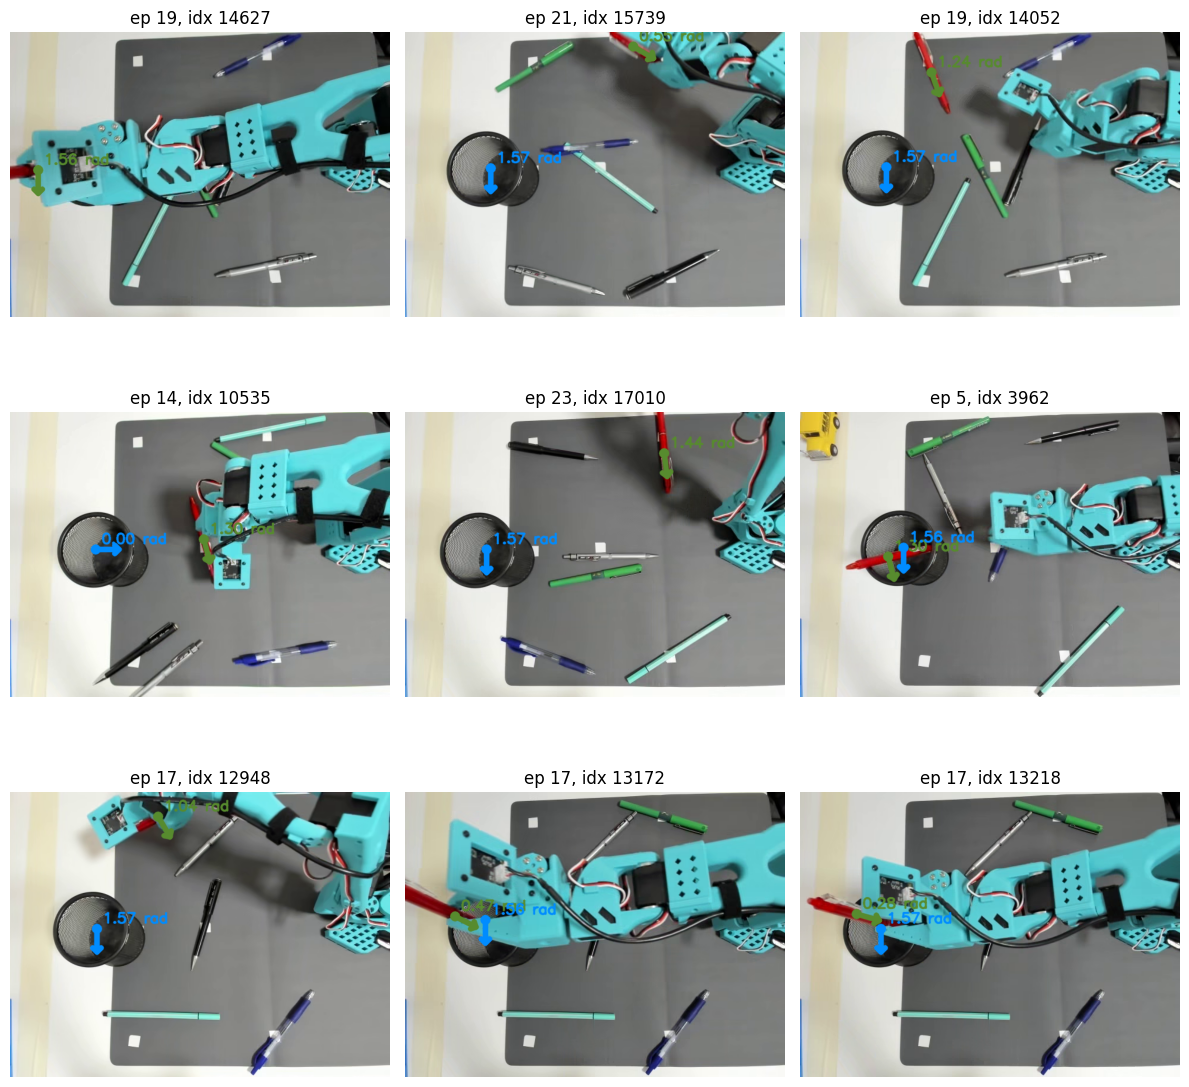

In [20]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

for ax in axes:
    # pick random episode
    ep = np.random.choice(ds.meta.episodes['episode_index'])
    start = ds.meta.episodes['dataset_from_index'][ep]
    end   = ds.meta.episodes['dataset_to_index'][ep]

    # pick random frame inside episode
    idx = np.random.randint(start, end)

    # load episode json
    json_path = ann_json_dir / f"ep_{ep:03d}.json"
    with open(json_path, "r") as f:
        ep_data = json.load(f)

    # lookup vec for frame
    rec = next(r for r in ep_data if r["frame_index"] == idx)
    sx, sy, sr, tx, ty, tr = rec["vec"]

    # load image
    frame = ds[idx]["observation.images.top_cam"]
    img = to_pil_image(frame.cpu())
    H, W = img.height, img.width

    # draw source + target
    img = yolo_draw_center_orientation(img, sx*W, sy*H, sr, YOLO_ANN_COLORS["source"])
    img = yolo_draw_center_orientation(img, tx*W, ty*H, tr, YOLO_ANN_COLORS["target"])

    # show
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"ep {ep}, idx {idx}")

plt.tight_layout()
plt.show()


### 4. Add YOLO data as new feature in dataset
**! DANGER !**

Remove feature if the same feature already exists & add new feature to DS:

In [ ]:
if new_feature_data is not None:
    if RM_FEATURE:
        new_ds = remove_feature(
            ds,
            feature_names = new_feature_name,
            output_dir    = new_output_dir+"-delete_me",
            repo_id       = new_repo_id+"-delete_me"
        )
    else:
        # just for continuity
        new_ds = ds

    # add new feature in any case to new_ds
    new_ds = add_feature(
        new_ds,
        feature_name   = new_feature_name,
        feature_values = new_feature_data,
        feature_info   = new_feature_meta,
        output_dir     = new_output_dir,
        repo_id        = new_repo_id.__str__()
    )
# if empty new feature
else:
    raise NotImplementedError

Copying observation.images.top_cam videos: 100%|██████████| 1/1 [00:00<00:00,  8.56it/s]
Generating train split: 25 examples [00:00, 1686.68 examples/s]
Generating train split: 18491 examples [00:00, 2002449.60 examples/s]


In [34]:
if PUSH_TO_HUB:
    new_ds.push_to_hub()
    # ds.push_to_hub()
    # from huggingface_hub import delete_folder
    # delete_folder('bboxes', ds.repo_id, repo_type='dataset')

It seems you are trying to upload a large folder at once. This might take some time and then fail if the folder is too large. For such cases, it is recommended to upload in smaller batches or to use `HfApi().upload_large_folder(...)`/`hf upload-large-folder` instead. For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/upload#upload-a-large-folder.
Processing Files (430 / 430): |          |  611MB /     ?B, 61.7MB/s      
New Data Upload: |          |  230MB /     ?B, 1.13MB/s  


### 5. Test new DS

In [29]:
pprint(new_ds.features[new_feature_name])

{'dtype': 'float32',
 'names': ['source_x',
           'source_y',
           'source_r',
           'target_x',
           'target_y',
           'target_r'],
 'shape': (6,)}


Sample from the DS itself:

/home/jonathan/miniforge3/envs/lerobot-sim-real-sim/lib/python3.10/site-packages/torchvision/io/_video_deprecation_warning.py:5: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(


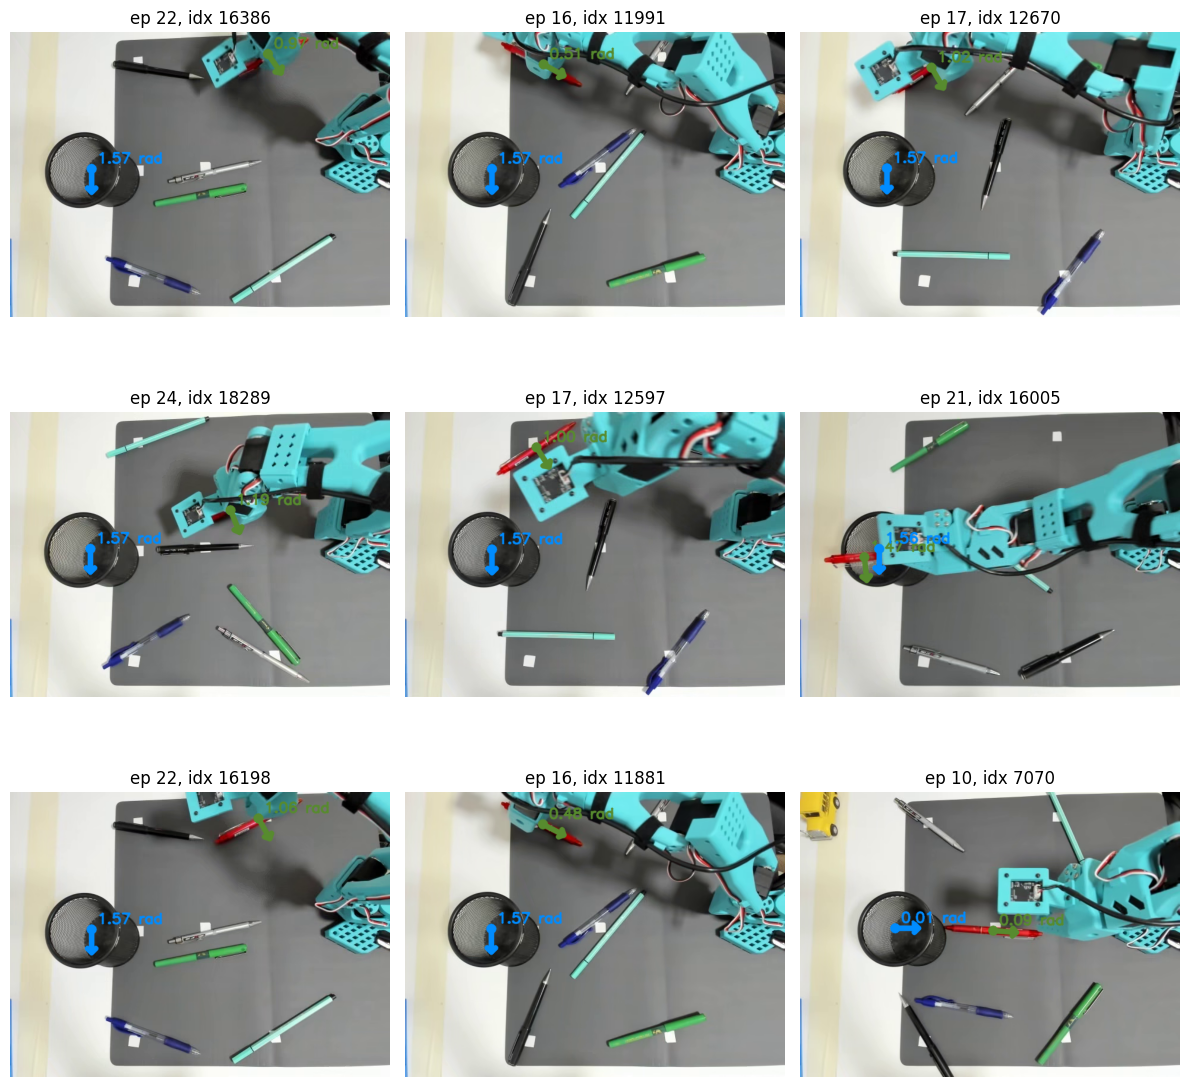

In [30]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

for ax in axes:
    # pick random episode and frame
    ep = np.random.choice(ds.meta.episodes['episode_index'])
    start = ds.meta.episodes['dataset_from_index'][ep]
    end   = ds.meta.episodes['dataset_to_index'][ep]

    # get data from ds
    idx = np.random.randint(start, end)
    sx, sy, sr, tx, ty, tr = new_ds[idx][new_feature_name]
    
    # load image
    frame = ds[idx]["observation.images.top_cam"]
    img = to_pil_image(frame.cpu())
    H, W = img.height, img.width

    # draw source + target
    img = yolo_draw_center_orientation(img, sx*W, sy*H, sr, YOLO_ANN_COLORS["source"])
    img = yolo_draw_center_orientation(img, tx*W, ty*H, tr, YOLO_ANN_COLORS["target"])

    # show
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"ep {ep}, idx {idx}")

plt.tight_layout()
plt.show()
